# Partie 4 : MLP pour la Régression - SOLUTIONS

**Objectif :** Montrer que les MLP ne servent pas uniquement à la classification, mais aussi à la régression.

**Outils :** Scikit-Learn (MLPRegressor), NumPy, Matplotlib.

---

## Exercice 4.1 : Génération du Dataset


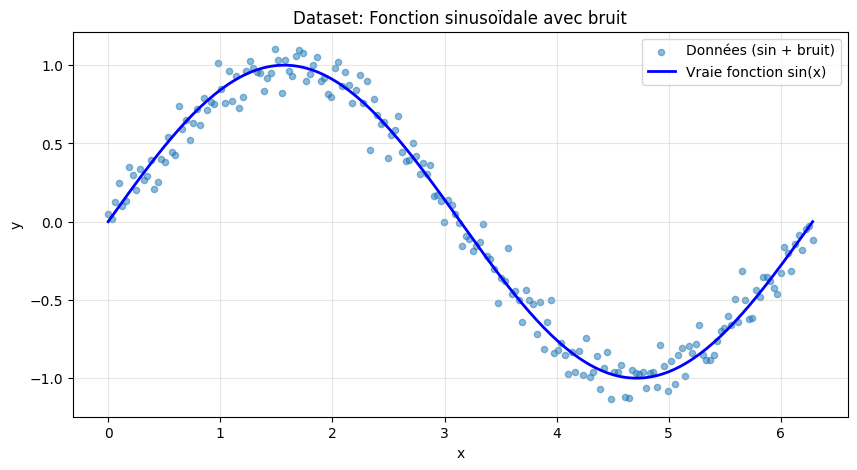

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

# Génération du dataset
np.random.seed(42)
X = np.linspace(0, 2 * np.pi, 200).reshape(-1, 1)  # 200 points entre 0 et 2π
noise = np.random.normal(0, 0.1, X.shape)           # Bruit gaussien
y_true = np.sin(X).ravel()                          # Vraie fonction sin(x)
y = y_true + noise.ravel()                          # sin(x) + bruit

# Visualisation des données
plt.figure(figsize=(10, 5))
plt.scatter(X, y, alpha=0.5, label='Données (sin + bruit)', s=20)
plt.plot(X, y_true, 'b-', linewidth=2, label='Vraie fonction sin(x)')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Dataset: Fonction sinusoïdale avec bruit')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Division train/test et normalisation
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_all_scaled = scaler.transform(X)


---

## Exercice 4.2 : MLP avec activation ReLU


In [2]:
# MLP avec activation ReLU (non-linéaire)
print("Entraînement MLP avec ReLU...")
mlp_relu = MLPRegressor(hidden_layer_sizes=(64, 32), activation='relu', max_iter=1000, random_state=42)
mlp_relu.fit(X_train_scaled, y_train)
y_pred_relu = mlp_relu.predict(X_all_scaled)

mse_relu = mean_squared_error(y_test, mlp_relu.predict(X_test_scaled))
r2_relu = r2_score(y_test, mlp_relu.predict(X_test_scaled))
print(f"  MSE: {mse_relu:.4f}")
print(f"  R² Score: {r2_relu:.4f}")

# MLP avec activation linéaire (identity)
print("\nEntraînement MLP avec activation LINÉAIRE...")
mlp_linear = MLPRegressor(hidden_layer_sizes=(64, 32), activation='identity', max_iter=1000, random_state=42)
mlp_linear.fit(X_train_scaled, y_train)
y_pred_linear = mlp_linear.predict(X_all_scaled)

mse_linear = mean_squared_error(y_test, mlp_linear.predict(X_test_scaled))
r2_linear = r2_score(y_test, mlp_linear.predict(X_test_scaled))
print(f"  MSE: {mse_linear:.4f}")
print(f"  R² Score: {r2_linear:.4f}")


Entraînement MLP avec ReLU...
  MSE: 0.0121
  R² Score: 0.9784

Entraînement MLP avec activation LINÉAIRE...
  MSE: 0.1931
  R² Score: 0.6539


---

## Exercice 4.3 : Visualisation Comparative


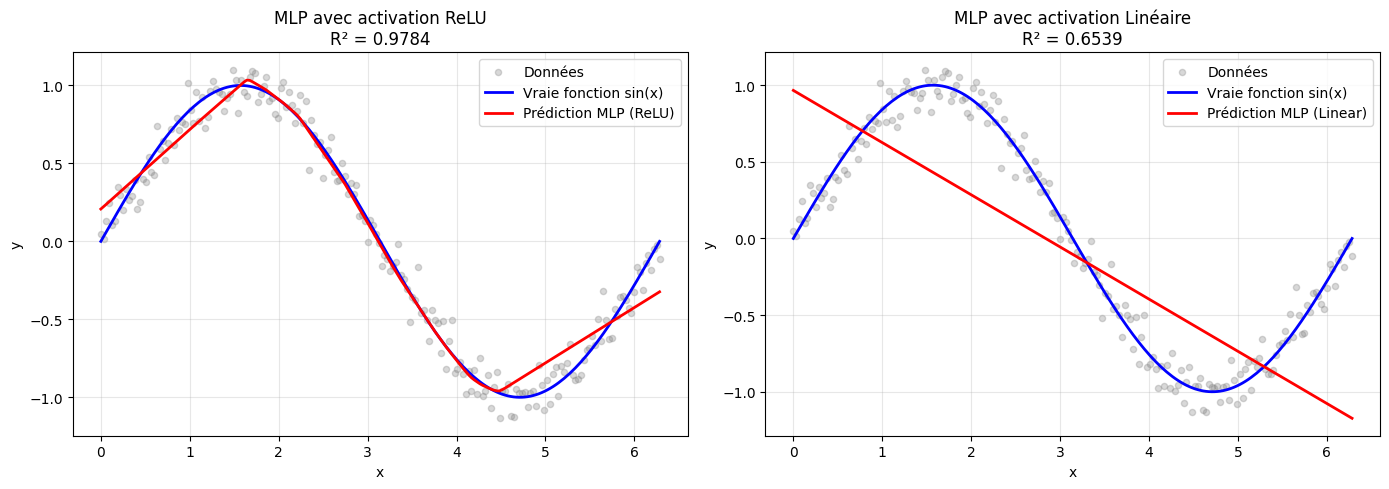

In [3]:
# Visualisation comparative
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Graphique 1: MLP avec ReLU
ax1 = axes[0]
ax1.scatter(X, y, alpha=0.3, label='Données', s=20, color='gray')
ax1.plot(X, y_true, 'b-', linewidth=2, label='Vraie fonction sin(x)')
ax1.plot(X, y_pred_relu, 'r-', linewidth=2, label='Prédiction MLP (ReLU)')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_title(f'MLP avec activation ReLU\nR² = {r2_relu:.4f}')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Graphique 2: MLP avec activation linéaire
ax2 = axes[1]
ax2.scatter(X, y, alpha=0.3, label='Données', s=20, color='gray')
ax2.plot(X, y_true, 'b-', linewidth=2, label='Vraie fonction sin(x)')
ax2.plot(X, y_pred_linear, 'r-', linewidth=2, label='Prédiction MLP (Linear)')
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_title(f'MLP avec activation Linéaire\nR² = {r2_linear:.4f}')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### Observation

La courbe rouge (prédiction) avec l'activation **LINÉAIRE** est une **DROITE** !
Elle ne peut absolument pas suivre la courbe sinusoïdale.

**Pourquoi ?**

- Avec des activations linéaires, l'empilement de couches équivaut à une seule transformation linéaire : $y = ax + b$
- Peu importe le nombre de couches ou de neurones, le résultat final est toujours une fonction **LINÉAIRE** de l'entrée
- Pour approximer une courbe (fonction non-linéaire), il **FAUT** des fonctions d'activation non-linéaires (ReLU, tanh, sigmoid...)

**C'est la preuve visuelle que la non-linéarité est ESSENTIELLE !**

---

## Points clés à retenir

1. **Les MLP peuvent faire de la régression** (pas seulement de la classification)
2. **La non-linéarité est essentielle** pour modéliser des courbes
3. **Théorème d'approximation universelle** : Un MLP avec une couche cachée suffisamment large peut approximer n'importe quelle fonction continue
